In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, r2_score, classification_report,mean_squared_error

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\nikhi\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
df = pd.read_csv('Reviews.csv', usecols=[
    'UserId', 'Score', 'Text',
    'HelpfulnessNumerator', 'HelpfulnessDenominator'
])
print('Shape:', df.shape)
print()
print('Missing values:')
print(df.isnull().sum())
print()
print('Score distribution:')
print(df['Score'].value_counts().sort_index())
print()
df.head()

Shape: (568454, 5)

Missing values:
UserId                    0
HelpfulnessNumerator      0
HelpfulnessDenominator    0
Score                     0
Text                      0
dtype: int64

Score distribution:
Score
1     52268
2     29769
3     42640
4     80655
5    363122
Name: count, dtype: int64



,UserId,HelpfulnessNumerator,HelpfulnessDenominator,Score,Text
0,A3SGXH7AUHU8GW,1,1,5,I have bought several of the Vitality canned d...
1,A1D87F6ZCVE5NK,0,0,1,Product arrived labeled as Jumbo Salted Peanut...
2,ABXLMWJIXXAIN,1,1,4,This is a confection that has been around a fe...
3,A395BORC6FGVXV,3,3,2,If you are looking for the secret ingredient i...
4,A1UQRSCLF8GW1T,0,0,5,Great taffy at a great price. There was a wid...


In [19]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 568454 entries, 0 to 568453
Data columns (total 5 columns):
 #   Column                  Non-Null Count   Dtype
---  ------                  --------------   -----
 0   UserId                  568454 non-null  str  
 1   HelpfulnessNumerator    568454 non-null  int64
 2   HelpfulnessDenominator  568454 non-null  int64
 3   Score                   568454 non-null  int64
 4   Text                    568454 non-null  str  
dtypes: int64(3), str(2)
memory usage: 21.7 MB


In [20]:
df=df[df['Score']!=3].copy()
df['Sentiment'] = df['Score'].apply(lambda x: 1 if x >= 4 else 0)

print('After removing neutrals:', df.shape)
print()
print('Sentiment distribution:')
print(df['Sentiment'].value_counts())
print()
print('Positive:', df['Sentiment'].sum())
print('Negative:', (df['Sentiment'] == 0).sum())

After removing neutrals: (525814, 6)

Sentiment distribution:
Sentiment
1    443777
0     82037
Name: count, dtype: int64

Positive: 443777
Negative: 82037


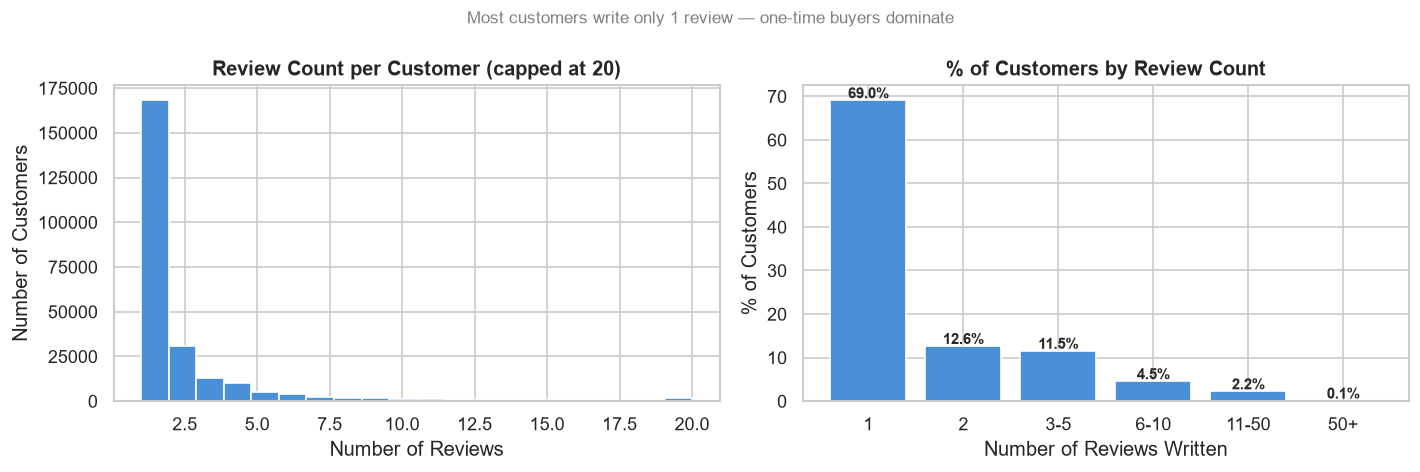

Customers with only 1 review: 168,068 (69.0%)
Most active customer: 425 reviews


In [21]:
# How many reviews does each customer write?
customer_review_counts = df.groupby('UserId')['Score'].count()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram — capped at 20 for readability
axes[0].hist(customer_review_counts.clip(upper=20), bins=20,
             color='#4A90D9', edgecolor='white')
axes[0].set_title('Review Count per Customer (capped at 20)',
                  fontweight='bold')
axes[0].set_xlabel('Number of Reviews')
axes[0].set_ylabel('Number of Customers')

# Bar chart — % of customers by review count bucket
buckets = pd.cut(customer_review_counts,
                 bins=[0,1,2,5,10,50,500],
                 labels=['1','2','3-5','6-10','11-50','50+'])
bucket_pct = buckets.value_counts(normalize=True).sort_index() * 100
axes[1].bar(bucket_pct.index, bucket_pct.values,
            color='#4A90D9', edgecolor='white')
axes[1].set_title('% of Customers by Review Count',
                  fontweight='bold')
axes[1].set_xlabel('Number of Reviews Written')
axes[1].set_ylabel('% of Customers')
for i, val in enumerate(bucket_pct.values):
    axes[1].text(i, val + 0.5, f'{val:.1f}%',
                 ha='center', fontweight='bold', fontsize=9)

plt.suptitle('Most customers write only 1 review — one-time buyers dominate',
             fontsize=10, color='gray')
plt.tight_layout()
plt.savefig('viz1_review_count_distribution.png', bbox_inches='tight')
plt.show()

print(f'Customers with only 1 review: '
      f'{(customer_review_counts==1).sum():,} '
      f'({(customer_review_counts==1).mean()*100:.1f}%)')
print(f'Most active customer: {customer_review_counts.max()} reviews')

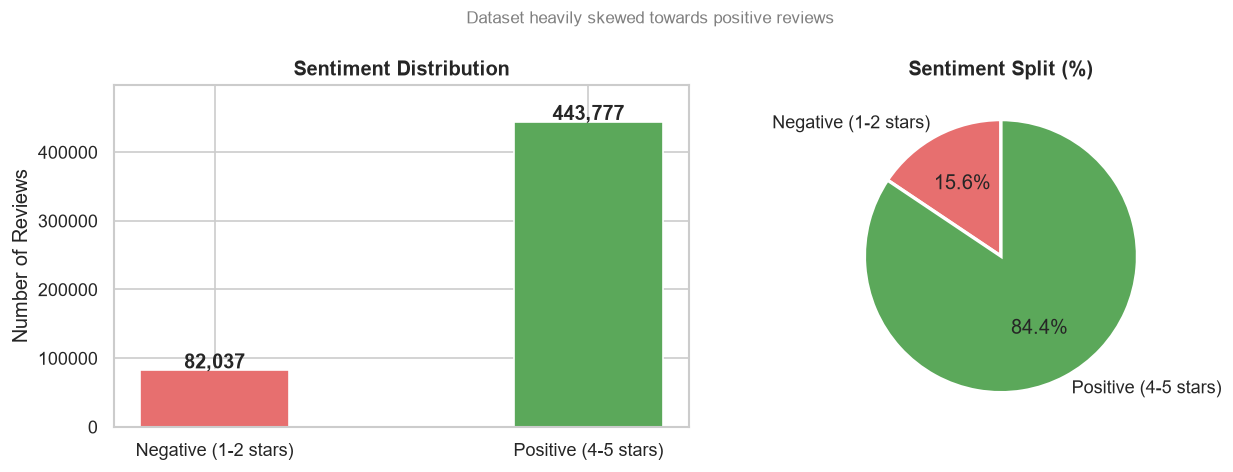

In [22]:
counts = df['Sentiment'].value_counts().sort_index()
labels = ['Negative (1-2 stars)', 'Positive (4-5 stars)']
colors = ['#E76F6F', '#5BA85A']

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Bar chart
bars = axes[0].bar(labels, counts.values,
                   color=colors, edgecolor='white', width=0.4)
axes[0].set_title('Sentiment Distribution', fontweight='bold')
axes[0].set_ylabel('Number of Reviews')
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 3000,
                 f'{val:,}', ha='center', fontweight='bold')
axes[0].set_ylim(0, max(counts.values) * 1.12)

# Pie chart
axes[1].pie(counts.values, labels=labels, colors=colors,
            autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Sentiment Split (%)', fontweight='bold')

plt.suptitle('Dataset heavily skewed towards positive reviews',
             fontsize=10, color='gray')
plt.tight_layout()
plt.savefig('viz2_sentiment_distribution.png', bbox_inches='tight')
plt.show()

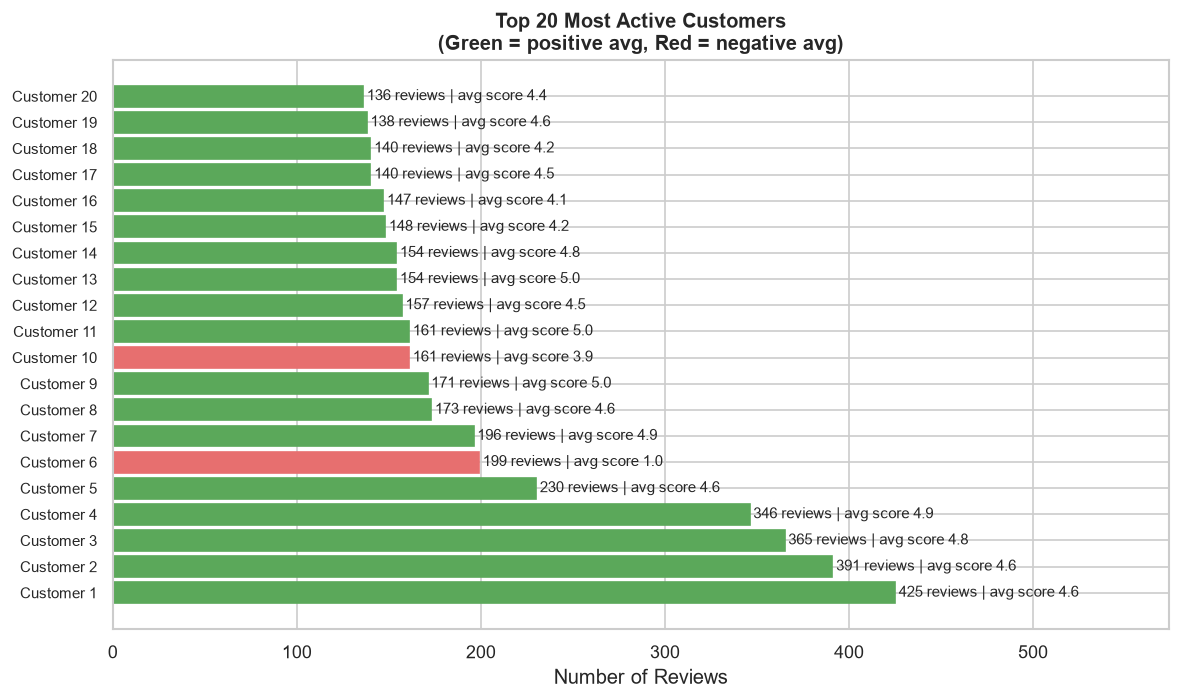

Top 3 most active customers:
                ReviewCount  AvgScore
UserId                               
A3OXHLG6DIBRW8          425  4.618824
A1YUL9PCJR3JTY          391  4.608696
AY12DBB0U420B           365  4.756164


In [23]:
top20 = df.groupby('UserId').agg(
    ReviewCount = ('Score', 'count'),
    AvgScore    = ('Score', 'mean')
).sort_values('ReviewCount', ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(range(20), top20['ReviewCount'].values,
               color='#4A90D9', edgecolor='white')

# Color by avg score
for i, (bar, avg) in enumerate(zip(bars, top20['AvgScore'].values)):
    col = '#5BA85A' if avg >= 4 else '#E76F6F'
    bar.set_color(col)
    ax.text(bar.get_width() + 2,
            bar.get_y() + bar.get_height()/2,
            f'{int(bar.get_width())} reviews | avg score {avg:.1f}',
            va='center', fontsize=9)

ax.set_yticks(range(20))
ax.set_yticklabels([f'Customer {i+1}' for i in range(20)], fontsize=9)
ax.set_xlabel('Number of Reviews')
ax.set_title('Top 20 Most Active Customers\n(Green = positive avg, Red = negative avg)',
             fontweight='bold')
ax.set_xlim(0, top20['ReviewCount'].max() * 1.35)
plt.tight_layout()
plt.savefig('viz3_top20_customers.png', bbox_inches='tight')
plt.show()

print('Top 3 most active customers:')
print(top20.head(3))

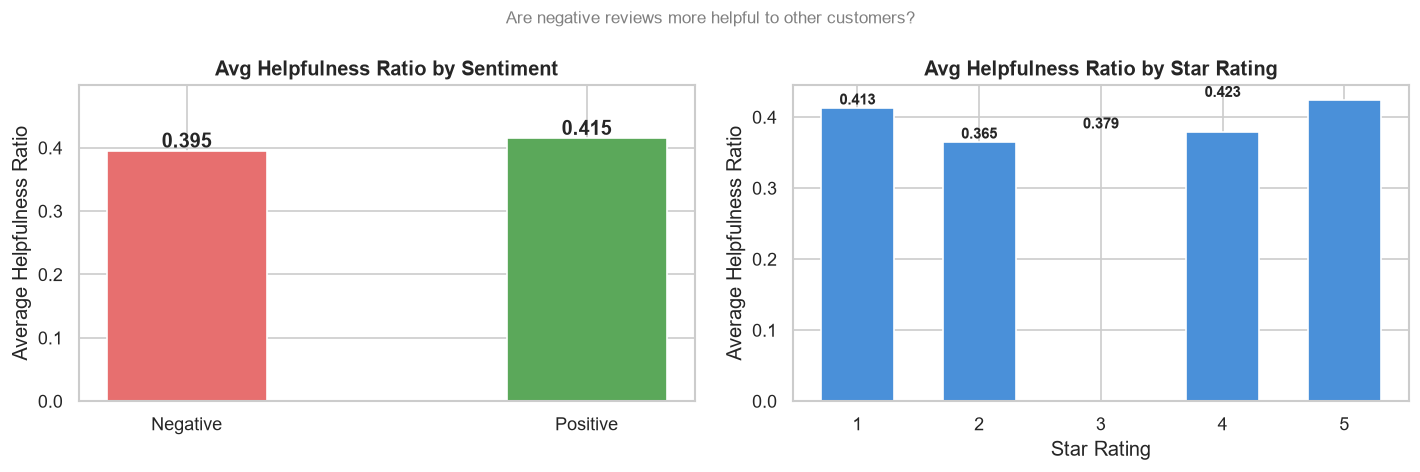

Avg helpfulness by sentiment:
Negative    0.395239
Positive    0.415249
Name: HelpfulnessRatio, dtype: float64


In [24]:
# Helpfulness ratio = helpful votes / total votes
df['HelpfulnessRatio'] = df['HelpfulnessNumerator'] / df['HelpfulnessDenominator'].replace(0, 1)

# Groupby sentiment — average helpfulness per group
help_by_sentiment = df.groupby('Sentiment')['HelpfulnessRatio'].mean()
help_by_sentiment.index = ['Negative', 'Positive']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart using groupby result
bars = axes[0].bar(help_by_sentiment.index,
                   help_by_sentiment.values,
                   color=['#E76F6F', '#5BA85A'],
                   edgecolor='white', width=0.4)
axes[0].set_title('Avg Helpfulness Ratio by Sentiment', fontweight='bold')
axes[0].set_ylabel('Average Helpfulness Ratio')
for bar, val in zip(bars, help_by_sentiment.values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.005,
                 f'{val:.3f}', ha='center', fontweight='bold')
axes[0].set_ylim(0, max(help_by_sentiment.values) * 1.2)

# Groupby score — avg helpfulness per star rating
help_by_score = df.groupby('Score')['HelpfulnessRatio'].mean()
axes[1].bar(help_by_score.index, help_by_score.values,
            color='#4A90D9', edgecolor='white', width=0.6)
axes[1].set_title('Avg Helpfulness Ratio by Star Rating',
                  fontweight='bold')
axes[1].set_xlabel('Star Rating')
axes[1].set_ylabel('Average Helpfulness Ratio')
for i, val in enumerate(help_by_score.values):
    axes[1].text(i+1, val + 0.005, f'{val:.3f}',
                 ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Are negative reviews more helpful to other customers?',
             fontsize=10, color='gray')
plt.tight_layout()
plt.savefig('viz4_helpfulness_by_sentiment.png', bbox_inches='tight')
plt.show()

print('Avg helpfulness by sentiment:')
print(help_by_sentiment)

In [46]:
# Your exact preprocessing pipeline
ps = PorterStemmer()
all_stopwords = stopwords.words('english')
all_stopwords.remove('not')
all_stopwords = set(all_stopwords)

def preprocess(text):
    review = re.sub('[^a-zA-Z]', ' ', str(text))
    review = review.lower().split()
    review = [ps.stem(word) for word in review
              if word not in all_stopwords]
    return ' '.join(review)

print('Preprocessing reviews... (takes 3-5 mins)')
df['CleanText'] = df['Text'].apply(preprocess)  
print(f'Done! {len(df):,} reviews preprocessed')
print()
print('Sample cleaned review:')
print(df['CleanText'].iloc[0])

Preprocessing reviews... (takes 3-5 mins)
Done! 525,814 reviews preprocessed

Sample cleaned review:
bought sever vital can dog food product found good qualiti product look like stew process meat smell better labrador finicki appreci product better


In [48]:
# Vectorize using your exact CountVectorizer from Amazon project
cv = CountVectorizer(max_features=5000)
X_nlp = cv.fit_transform(df['CleanText'])
y_nlp = df['Sentiment']

# Train test split
X_train_nlp, X_test_nlp, y_train_nlp, y_test_nlp = train_test_split(
    X_nlp, y_nlp, test_size=0.2, random_state=42, stratify=y_nlp
)

# Logistic Regression — best performer from Amazon project
lr_nlp = LogisticRegression(max_iter=1000, random_state=42)
lr_nlp.fit(X_train_nlp, y_train_nlp)
y_pred_nlp = lr_nlp.predict(X_test_nlp)

print('=== NLP Sentiment Classifier ===')
print(f'Accuracy: {accuracy_score(y_test_nlp, y_pred_nlp):.4f}')
print()
print(classification_report(y_test_nlp, y_pred_nlp,
      target_names=['Negative', 'Positive']))

=== NLP Sentiment Classifier ===
Accuracy: 0.9286

              precision    recall  f1-score   support

    Negative       0.83      0.68      0.75     16407
    Positive       0.94      0.97      0.96     88756

    accuracy                           0.93    105163
   macro avg       0.89      0.83      0.85    105163
weighted avg       0.93      0.93      0.93    105163



In [25]:
# Aggregate all reviews by customer — one row per customer
customer_df = df.groupby('UserId').agg(
    ReviewCount      = ('Score', 'count'),
    AvgScore         = ('Score', 'mean'),
    AvgSentiment     = ('Sentiment', 'mean'),
    AvgHelpfulness   = ('HelpfulnessRatio', 'mean'),
    TotalHelpful     = ('HelpfulnessNumerator', 'sum')
).reset_index()

print('Customer profile shape:', customer_df.shape)
print()
print('Sample customer profiles:')
print(customer_df.head(10))
print()
print('Customer profile stats:')
print(customer_df.describe().round(2))

Customer profile shape: (243414, 6)

Sample customer profiles:
               UserId  ReviewCount  AvgScore  AvgSentiment  AvgHelpfulness  \
0  #oc-R103C0QSV1DF5E            1       5.0           1.0        0.500000   
1  #oc-R109MU5OBBZ59U            1       5.0           1.0        0.000000   
2  #oc-R10LFEMQEW6QGZ            1       5.0           1.0        0.000000   
3  #oc-R10UA029WVWIUI            1       1.0           0.0        0.000000   
4  #oc-R115TNMSPFT9I7            2       2.0           0.0        0.666667   
5  #oc-R119LM8D59ZW8Y            1       1.0           0.0        0.454545   
6  #oc-R11D9D7SHXIJB9            3       5.0           1.0        0.000000   
7  #oc-R11DNU2NBKQ23Z            2       1.0           0.0        0.000000   
8  #oc-R11O5J5ZVQE25C            3       5.0           1.0        0.000000   
9  #oc-R120LO6OLNDPCG            1       1.0           0.0        0.500000   

   TotalHelpful  
0             1  
1             0  
2             0  
3     

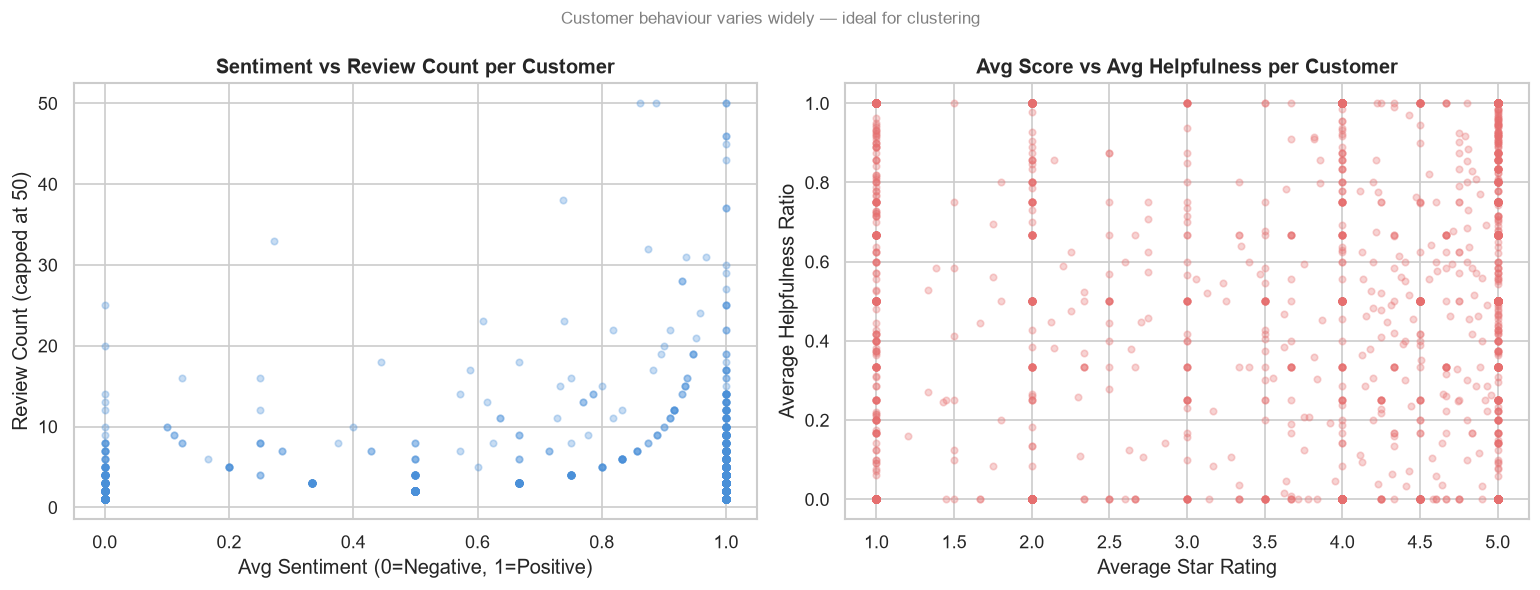

Customers with 100% positive sentiment: 194,525
Customers with 100% negative sentiment: 36,349


In [26]:
# Sample 5000 customers for readability
sample = customer_df.sample(5000, random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Scatter — AvgSentiment vs ReviewCount
axes[0].scatter(sample['AvgSentiment'],
                sample['ReviewCount'].clip(upper=50),
                alpha=0.3, s=15, color='#4A90D9')
axes[0].set_title('Sentiment vs Review Count per Customer',
                  fontweight='bold')
axes[0].set_xlabel('Avg Sentiment (0=Negative, 1=Positive)')
axes[0].set_ylabel('Review Count (capped at 50)')

# Scatter — AvgScore vs AvgHelpfulness
axes[1].scatter(sample['AvgScore'],
                sample['AvgHelpfulness'],
                alpha=0.3, s=15, color='#E76F6F')
axes[1].set_title('Avg Score vs Avg Helpfulness per Customer',
                  fontweight='bold')
axes[1].set_xlabel('Average Star Rating')
axes[1].set_ylabel('Average Helpfulness Ratio')

plt.suptitle('Customer behaviour varies widely — ideal for clustering',
             fontsize=10, color='gray')
plt.tight_layout()
plt.savefig('viz5_customer_scatter.png', bbox_inches='tight')
plt.show()

print(f'Customers with 100% positive sentiment: '
      f'{(customer_df["AvgSentiment"]==1.0).sum():,}')
print(f'Customers with 100% negative sentiment: '
      f'{(customer_df["AvgSentiment"]==0.0).sum():,}')

In [40]:
customer_df

,UserId,ReviewCount,AvgScore,AvgSentiment,AvgHelpfulness,TotalHelpful,Cluster
0,#oc-R103C0QSV1DF5E,1,5.000000,1.0,0.500000,1,1
1,#oc-R109MU5OBBZ59U,1,5.000000,1.0,0.000000,0,0
2,#oc-R10LFEMQEW6QGZ,1,5.000000,1.0,0.000000,0,0
3,#oc-R10UA029WVWIUI,1,1.000000,0.0,0.000000,0,2
4,#oc-R115TNMSPFT9I7,2,2.000000,0.0,0.666667,4,2
...,...,...,...,...,...,...,...
243409,AZZV9PDNMCOZW,3,4.666667,1.0,0.333333,1,0
243410,AZZVNIMTTMJH6,1,5.000000,1.0,0.000000,0,0
243411,AZZY649VYAHQS,1,5.000000,1.0,1.000000,1,1
243412,AZZYCJOJLUDYR,1,5.000000,1.0,0.000000,0,0


In [ ]:
# Select the 3 features for clustering
cluster_features = ['ReviewCount', 'AvgSentiment', 'AvgHelpfulness']

# Scale — KMeans is distance based so scaling is essential
scaler = StandardScaler()
cluster_scaled = scaler.fit_transform(customer_df[cluster_features])

print('Cluster features shape:', cluster_scaled.shape)
print()
print('After scaling — mean should be ~0, std should be ~1:')
print(pd.DataFrame(cluster_scaled,
                   columns=cluster_features).describe().round(2))

Cluster features shape: (243414, 3)

After scaling — mean should be ~0, std should be ~1:
       ReviewCount  AvgSentiment  AvgHelpfulness
count    243414.00     243414.00       243414.00
mean          0.00          0.00           -0.00
std           1.00          1.00            1.00
min          -0.28         -2.30           -0.95
25%          -0.28          0.47           -0.95
50%          -0.28          0.47           -0.38
75%          -0.04          0.47            1.31
max         101.57          0.47            1.31


In [29]:
# # Drop any nulls in customer profile
# customer_df.dropna(inplace=True)
# print('Customer profile after dropping nulls:', customer_df.shape)
# print()

# # Select 3 features for clustering
# cluster_features = ['ReviewCount', 'AvgSentiment', 'AvgHelpfulness']
# X_cluster = customer_df[cluster_features]

# # Scale — KMeans is distance based so scaling is essential
# scaler = StandardScaler()
# cluster_scaled = scaler.fit_transform(X_cluster)

# print('Scaled features shape:', cluster_scaled.shape)
# print('Mean after scaling (should be ~0):',
#       cluster_scaled.mean(axis=0).round(3))
# print('Std after scaling (should be ~1):',
#       cluster_scaled.std(axis=0).round(3))

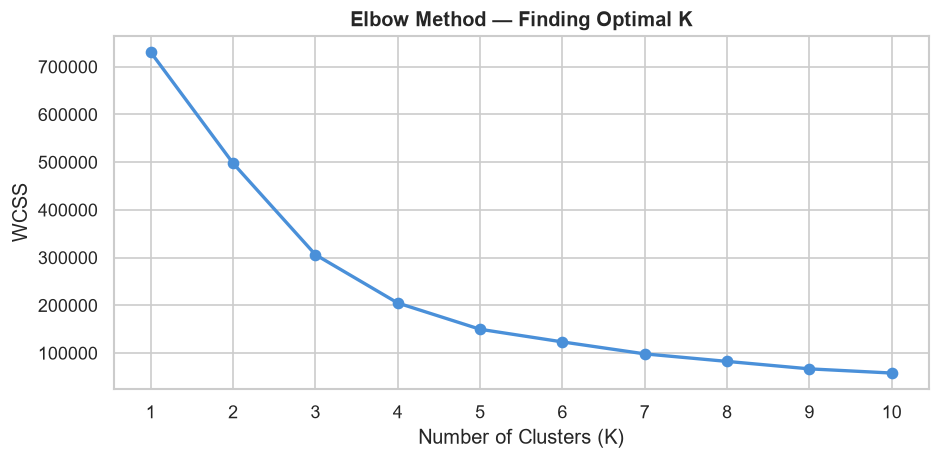

In [30]:
wcss = []
for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(cluster_scaled)
    wcss.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(range(1, 11), wcss, marker='o', color='#4A90D9',
         linewidth=2, markersize=6)
plt.title('Elbow Method — Finding Optimal K', fontweight='bold')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.xticks(range(1, 11))
plt.tight_layout()
plt.savefig('viz6_elbow.png', bbox_inches='tight')
plt.show()

In [33]:
kmeans=KMeans(n_clusters=4,init='k-means++',random_state=42)
customer_df['Cluster']=kmeans.fit_predict(cluster_scaled)
y_kmeans=kmeans.fit_predict(cluster_scaled)
print('Cluster sizes:')
print(customer_df['Cluster'].value_counts().sort_index())
print()
print('Cluster profiles:')
print(customer_df.groupby('Cluster')[
    ['ReviewCount', 'AvgSentiment', 'AvgHelpfulness']
].mean().round(2))

Cluster sizes:
Cluster
0    109531
1     91563
2     39894
3      2426
Name: count, dtype: int64

Cluster profiles:
         ReviewCount  AvgSentiment  AvgHelpfulness
Cluster                                           
0               1.99          0.99            0.03
1               1.85          0.99            0.90
2               1.71          0.04            0.41
3              29.09          0.88            0.41


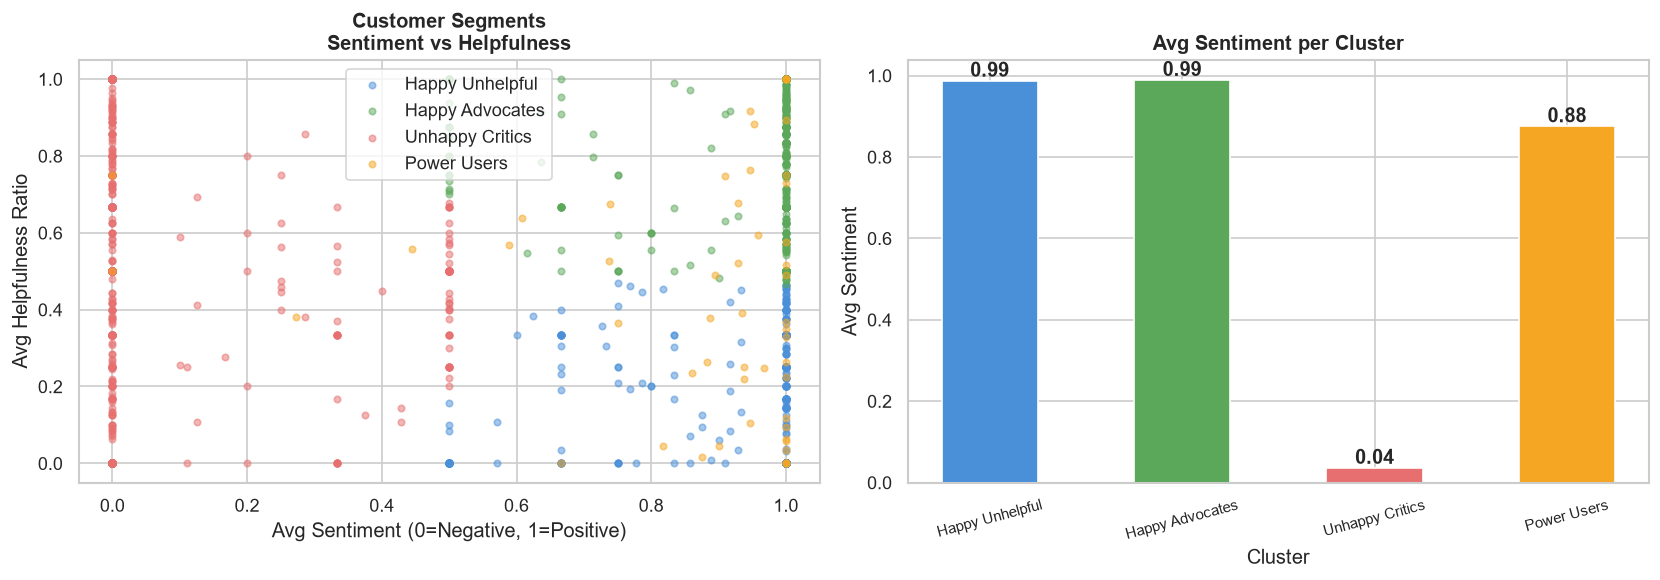

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#4A90D9', '#5BA85A', '#E76F6F', '#F5A623']
labels = ['Happy Unhelpful', 'Happy Advocates',
          'Unhappy Critics', 'Power Users']

# Scatter — AvgSentiment vs AvgHelpfulness colored by cluster
sample = customer_df.sample(5000, random_state=42)
for c in range(4):
    mask = sample['Cluster'] == c
    axes[0].scatter(sample[mask]['AvgSentiment'],
                    sample[mask]['AvgHelpfulness'],
                    c=colors[c], label=labels[c],
                    alpha=0.5, s=15)
axes[0].set_title('Customer Segments\nSentiment vs Helpfulness',
                  fontweight='bold')
axes[0].set_xlabel('Avg Sentiment (0=Negative, 1=Positive)')
axes[0].set_ylabel('Avg Helpfulness Ratio')
axes[0].legend()

# Bar chart — avg sentiment per cluster
avg_sentiment = customer_df.groupby('Cluster')['AvgSentiment'].mean()
bars = axes[1].bar(range(4), avg_sentiment.values,
                   color=colors, edgecolor='white', width=0.5)
axes[1].set_title('Avg Sentiment per Cluster', fontweight='bold')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Avg Sentiment')
axes[1].set_xticks(range(4))
axes[1].set_xticklabels(labels, rotation=15, fontsize=9)
for bar, val in zip(bars, avg_sentiment.values):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.01,
                 f'{val:.2f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('viz7_clusters.png', bbox_inches='tight')
plt.show()

In [37]:
cluster_scaled

array([[-0.27867781,  0.46836751,  0.17975547],
       [-0.27867781,  0.46836751, -0.94698276],
       [-0.27867781,  0.46836751, -0.94698276],
       ...,
       [-0.27867781,  0.46836751,  1.30649369],
       [-0.27867781,  0.46836751, -0.94698276],
       [-0.27867781, -2.30061617, -0.94698276]], shape=(243414, 3))

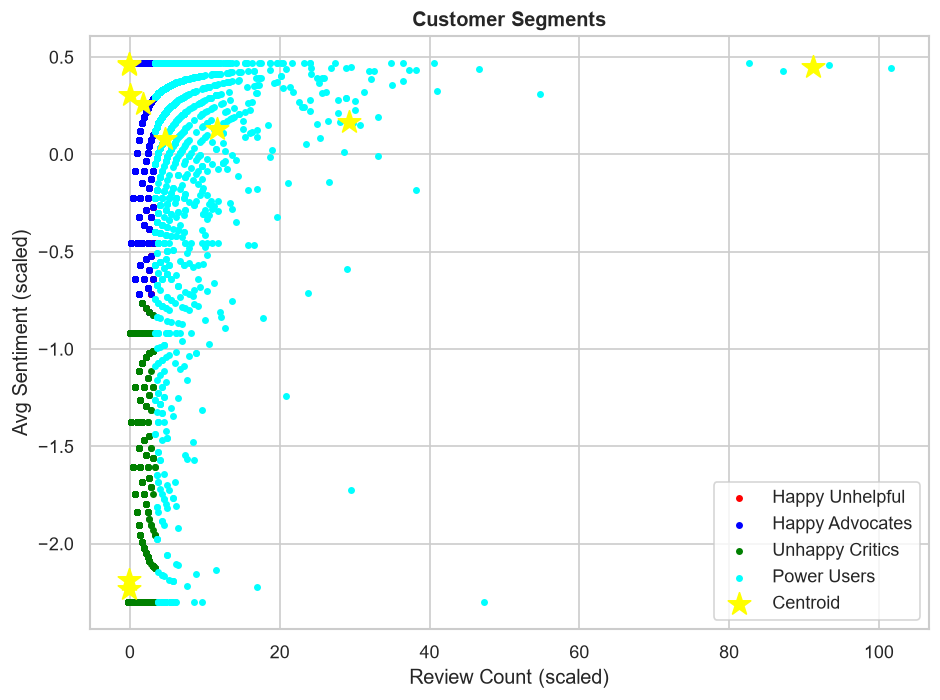

In [39]:
y_kmeans = customer_df['Cluster'].values

plt.figure(figsize=(8, 6))
plt.scatter(cluster_scaled[y_kmeans==0, 0], cluster_scaled[y_kmeans==0, 1],
            s=10, c='red', label='Happy Unhelpful')
plt.scatter(cluster_scaled[y_kmeans==1, 0], cluster_scaled[y_kmeans==1, 1],
            s=10, c='blue', label='Happy Advocates')
plt.scatter(cluster_scaled[y_kmeans==2, 0], cluster_scaled[y_kmeans==2, 1],
            s=10, c='green', label='Unhappy Critics')
plt.scatter(cluster_scaled[y_kmeans==3, 0], cluster_scaled[y_kmeans==3, 1],
            s=10, c='cyan', label='Power Users')
plt.scatter(km.cluster_centers_[:, 0], km.cluster_centers_[:, 1],
            s=200, c='yellow', label='Centroid', marker='*')
plt.title('Customer Segments', fontweight='bold')
plt.xlabel('Review Count (scaled)')
plt.ylabel('Avg Sentiment (scaled)')
plt.legend()
plt.tight_layout()
plt.savefig('viz7_clusters.png', bbox_inches='tight')
plt.show()

In [43]:
# Target: ReviewCount — how engaged will this customer be?
# Features: AvgSentiment + AvgHelpfulness only
# Cluster is excluded — it was derived from ReviewCount itself

X = customer_df[['AvgSentiment', 'AvgHelpfulness']]
y = customer_df['ReviewCount']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)

print('=== Linear Regression Results ===')
print(f'R² Score : {r2_score(y_test, y_pred):.4f}')
print(f'RMSE     : {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}')
print()
print('Coefficients:')
for feature, coef in zip(X.columns, lr.coef_):
    print(f'  {feature:20s}: {coef:.4f}')
print(f'  {"Intercept":20s}: {lr.intercept_:.4f}')

=== Linear Regression Results ===
R² Score : 0.0004
RMSE     : 3.7346

Coefficients:
  AvgSentiment        : 0.2293
  AvgHelpfulness      : -0.0899
  Intercept           : 2.0077


In [44]:
# Better target: AvgScore — what rating will this customer give?
# This has a genuine relationship with sentiment and helpfulness

X = customer_df[['AvgSentiment', 'AvgHelpfulness']]
y = customer_df['AvgScore']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)

print('=== Linear Regression Results ===')
print(f'R² Score : {r2_score(y_test, y_pred):.4f}')
print(f'RMSE     : {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}')
print()
print('Coefficients:')
for feature, coef in zip(X.columns, lr.coef_):
    print(f'  {feature:20s}: {coef:.4f}')
print(f'  {"Intercept":20s}: {lr.intercept_:.4f}')

=== Linear Regression Results ===
R² Score : 0.9253
RMSE     : 0.3622

Coefficients:
  AvgSentiment        : 3.5293
  AvgHelpfulness      : 0.0065
  Intercept           : 1.3113


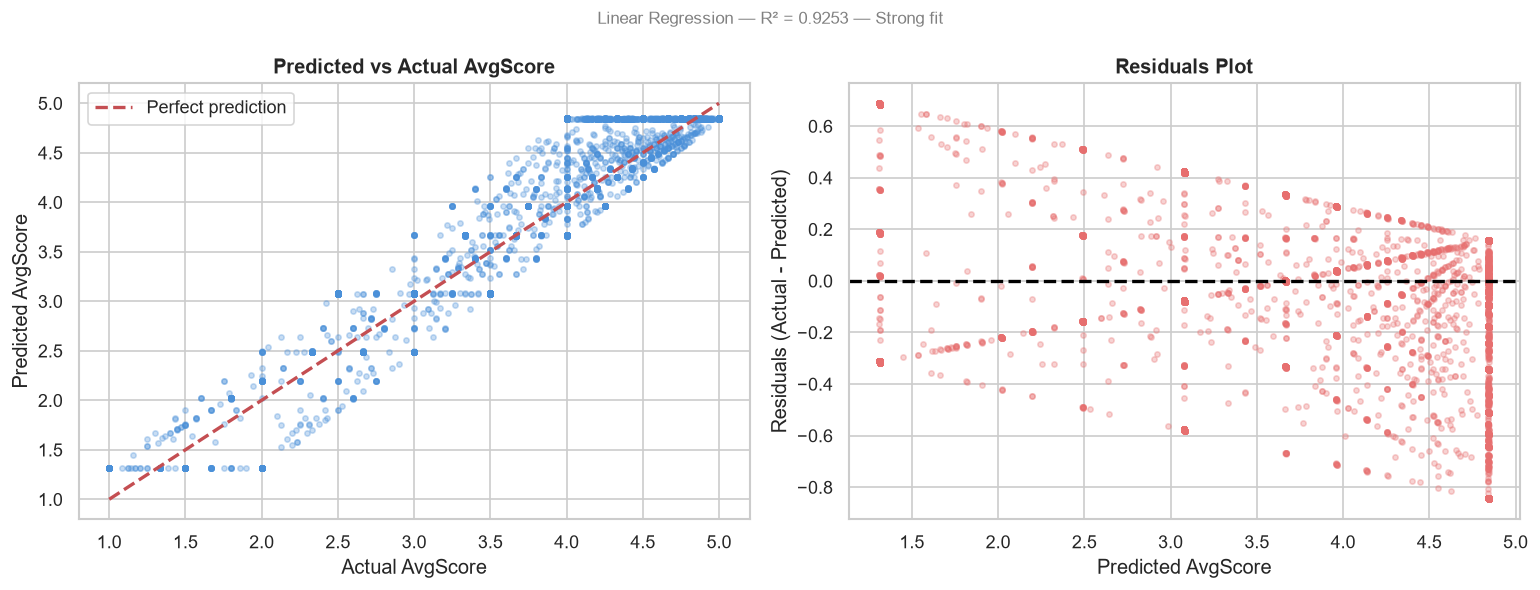

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Scatter — predicted vs actual
axes[0].scatter(y_test, y_pred, alpha=0.3, s=10, color='#4A90D9')
axes[0].plot([1, 5], [1, 5], 'r--', linewidth=2, label='Perfect prediction')
axes[0].set_title('Predicted vs Actual AvgScore', fontweight='bold')
axes[0].set_xlabel('Actual AvgScore')
axes[0].set_ylabel('Predicted AvgScore')
axes[0].legend()

# Residuals plot
residuals = y_test - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.3, s=10, color='#E76F6F')
axes[1].axhline(y=0, color='black', linewidth=2, linestyle='--')
axes[1].set_title('Residuals Plot', fontweight='bold')
axes[1].set_xlabel('Predicted AvgScore')
axes[1].set_ylabel('Residuals (Actual - Predicted)')

plt.suptitle(f'Linear Regression — R² = 0.9253 — Strong fit',
             fontsize=10, color='gray')
plt.tight_layout()
plt.savefig('viz8_regression_results.png', bbox_inches='tight')
plt.show()